# Demonstrate simulation and fit

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord

## Sources

In [2]:
from hierarchical_nu.source.parameter import Parameter
from hierarchical_nu.source.source import Sources, PointSource
from hierarchical_nu.detector.input import mceq

First set up the high-level parameters. The parameters defined here are singletons that can be accessed throught the program. The `src_index` and `diff_index` refer to the power law spectral index of the point sources and diffuse background. Currently, all sources share the same index, and the background can also be the same or defined separately. `L` and `F_diff` are used to set the normalisation of the point source and diffuse background spectra, defined at `Enorm`. `Emin` and `Emax` bound the source power law spectra for all sources, and define the energy band over which `L` is calculated. 

In [3]:
# define high-level parameters
Parameter.clear_registry()

# Point source
L = Parameter(
    1e48 * (u.erg / u.s), "luminosity", fixed=True, par_range=(0, 1e55) * (u.erg / u.s)
)
src_index = Parameter(2.0, "src_index", fixed=False, par_range=(1, 4))
ra = np.pi * u.rad
dec = np.deg2rad(5) * u.rad
z = 0.1

# Diffuse flux
diffuse_norm = Parameter(
    1e-13 * (1 / u.GeV / u.m**2 / u.s),
    "diffuse_norm",
    fixed=True,
    par_range=(0, 1) * (1 / u.GeV / u.m**2 / u.s),
)
diff_index = Parameter(2.5, "diff_index", fixed=False, par_range=(1, 4))
Enorm = Parameter(1e5 * u.GeV, "Enorm", fixed=True)

# Energy ranges
Emin = Parameter(1e2 * u.GeV, "Emin", fixed=True)
Emax = Parameter(1e8 * u.GeV, "Emax", fixed=True)
Emin_src = Parameter(Emin.value * (1 + z), "Emin_src", fixed=True)
Emax_src = Parameter(Emax.value * (1 + z), "Emax_src", fixed=True)
Emin_diff = Parameter(Emin.value, "Emin_diff", fixed=True)
Emax_diff = Parameter(Emax.value, "Emax_diff", fixed=True)

The minimum detected (i.e. reconstructed) energy is set using `Emin_det`. Different cuts can be used for different event types, or detector periods.

In [4]:
Emin_det = Parameter(6e2 * u.GeV, "Emin_det", fixed=True)

# Emin_det_northern_tracks = Parameter(1e5 * u.GeV, "Emin_det_northern_tracks", fixed=True)
# Emin_det_cascades = Parameter(6e4 * u.GeV, "Emin_det_cascades", fixed=True)
# Emin_det_IC86_II = Parameter(6e4 * u.GeV, "Emin_det_IC86_II", fixed=True)

Next, we use these high-level parameters to define sources. This can be done for either individual sources, or a list loaded from a file. For now we just work with a single point source. There are functions to add the different background components.

In [5]:
# Single PS for testing and usual background components
point_source = PointSource.make_powerlaw_source(
    "test", dec, ra, L, src_index, z, Emin_src, Emax_src
)

my_sources = Sources()
my_sources.add(point_source)

# auto diffuse component
my_sources.add_diffuse_component(
    diffuse_norm, Enorm.value, diff_index, Emin_diff, Emax_diff
)
my_sources.add_atmospheric_component(cache_dir=mceq)  # auto atmo component, from MCEq

## Simulation

In [6]:
from hierarchical_nu.simulation import Simulation
from hierarchical_nu.detector.icecube import IC86_II

In order to go from sources to a simulation, we need to specify an observation time and a detector model. The detector model defines the effective area, energy resolution and angular resolution to be simulated. The currently implemented options are `IC40`, `IC59`, `IC79`, `IC86_I` and `IC86_II`, corresponding to the different configurations of the IceCube Neutrino Observatory. These can also be combined into one simulation. The models should be used in conjunction with the correct `Edet_min`, as described above. If a parameter named `Edet_min` is on the stack it takes precedence over any detector model specific parameter, that is to say, those are disregarded. If detector model specific thresholds are used, they need to be defined for each used detector model.

Other detector mdoels, `NorthernTracks` and `Cascades`, are deprecated and no longer maintained.

The first time this code is run it will take ~2 min as the detector model setup is completed.

In [7]:
obs_time = 1 * u.day  # short time interval for testing

sim = Simulation(my_sources, [IC86_II], {IC86_II: obs_time})

Below are shown all the necessary steps to set up and run a simulation for clarity. There is also the handy `sim.setup_and_run()` option which calls everything.

Before starting, however, a region of interest needs to be defined in which simulations and fits are carried out. There are three options, `FullSkyROI`, `RectangularROI` and `CircularROI`, accepting different kinds of arguments.

In [ ]:
from hierarchical_nu.utils.roi import (
    ROIList,
    FullSkyROI,
    NorthernSkyROI,
    CircularROI,
    RectangularROI,
)

ROIList.clear_registry()

# roi = NorthernSkyROI()

source_coords = SkyCoord(ra=point_source.ra, dec=point_source.dec)
roi = CircularROI(source_coords, radius=10 * u.deg)
# roi = RectangularROI(RA_min=ra-5*u.deg, RA_max=ra+5*u.deg, DEC_min=dec-5*u.deg, DEC_max=dec+5*u.deg)

Run the precomputation necessary to compute the expected number of neutrino events in the detector.
The larger the ROI, the longer the diffuse exposure calculation will take due to the large number of pixels on the sky.

In [9]:
sim.precomputation(
    show_progress=True
)  # disable progress bar (default) when running on clusters to reduce clutter in log files

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

To check the expected number of events to be simulated:

In [10]:
print(sim.expected_Nnu_per_comp)  # Number of nu per source component
print(
    sim.Nex_et
)  # Number of nu per event type (useful if using e.g multiple detector periods)

[9.96020815e+00 8.40882757e-03 3.20756661e+00]
[[9.96020815e+00 8.40882757e-03 3.20756661e+00]]


In [11]:
sim.generate_stan_code()
sim.compile_stan_code()
sim.run(verbose=True, seed=99)
sim.save("test_sim_file.h5", overwrite=True)

11:02:50 - cmdstanpy - INFO - compiling stan file /home/iwsatlas1/kuhlmann/icecube/hierarchical_nu/examples/.stan_files/sim_code.stan to exe file /home/iwsatlas1/kuhlmann/icecube/hierarchical_nu/examples/.stan_files/sim_code
11:03:11 - cmdstanpy - INFO - compiled model executable: /home/iwsatlas1/kuhlmann/icecube/hierarchical_nu/examples/.stan_files/sim_code
11:03:11 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

11:03:11 - cmdstanpy - INFO - CmdStan done processing.


PosixPath('/home/iwsatlas1/kuhlmann/icecube/hierarchical_nu/examples/test_sim_file.h5')

For already compiled models that should be re-loaded there is a special method `sim.setup_stan_sim(".stan_files/sim_code")` which takes the filename of the compiled model as sole argument. Source selection should match up with the compiled model, otherwise cmdstanpy will complain. The `save` method (also the one of the fit) has a keyword `overwrite` which may be set to `True`. Otherwise, if a file of the specified name already exists, a time stamp is appended to the file name prior to saving.

We can visualise the simulation results to check that nothing weird is happening. For the default settings in this notebook, you should see around ~179 simulated events with a clear source in the centre of the sky. The source events are shown in red, diffuse background in blue at atmospheric events in green. The size of the event circles reflects their angular uncertainty (for track events this is exaggerated to make them visible).

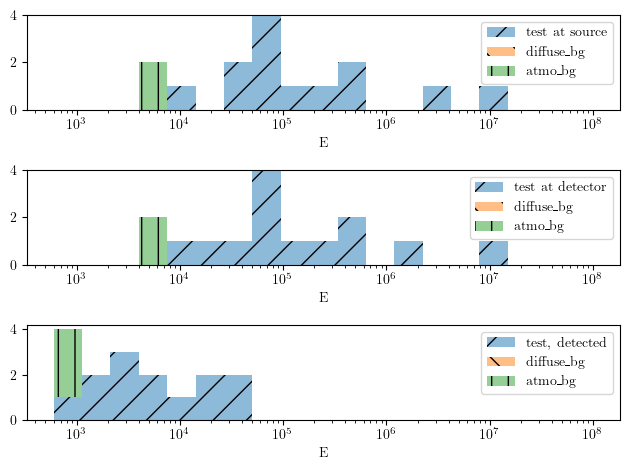

In [12]:
fig, axs = sim.show_spectrum()
# fig, axs = sim.show_spectrum(scale="log")  # displays plots with y axis on a log scale

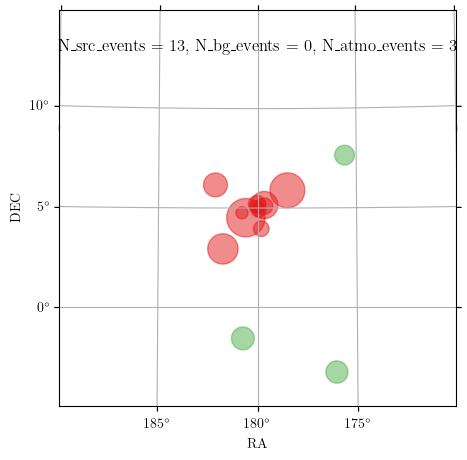

In [29]:
fig, ax = sim.show_skymap(
    subplot_kw={
        "projection": "astro degrees zoom",
        "center": source_coords,
        "radius": 10 * u.deg,
    }
)

ax.set_xlabel("RA")
ax.set_ylabel("DEC")
ax.grid()

## Fit 

In [15]:
from hierarchical_nu.events import Events
from hierarchical_nu.fit import StanFit
from hierarchical_nu.priors import (
    Priors,
    NormalPrior,
    LuminosityPrior,
    IndexPrior,
    DifferentialFluxPrior,
    FluxPrior,
)

We can start setting up the fit by loading the events from the output of our simulation. This file only contains the information we would have in a realistic data scenario (energies, directions, uncertainties, event types). We also need to specify the observation time and detector model for the fit, as for the simulation. Please make sure you are using the same ones in both for sensible results!

In [16]:
events = Events.from_file("test_sim_file.h5")

We can also define priors using the `Priors` interface, with some examples given below.

In [17]:
priors = Priors()

# Use true values for atmospheric and diffuse
flux_units = 1 / (u.m**2 * u.s)
atmo_flux = my_sources.atmospheric.flux_model.total_flux_int
diffuse_diff_flux = my_sources.diffuse.flux_model.total_flux(Enorm.value)

priors.atmospheric_flux = FluxPrior(mu=atmo_flux, sigma=0.02 * flux_units)
priors.luminosity = LuminosityPrior(mu=L.value, sigma=3)
priors.src_index = IndexPrior(mu=2.0, sigma=0.5)
priors.diff_index = IndexPrior(mu=2.5, sigma=0.2)
priors.diffuse_flux = DifferentialFluxPrior(
    NormalPrior, mu=diffuse_diff_flux, sigma=0.1 * diffuse_diff_flux
)

When defining the fit, we pass `my_sources` to the `StanFit`. This is used the define the source components, their free parameters and parameter boundaries. The values of the true source parameters define above in the simulation are not passed to the fit, and so can be set to arbitrary values. 

In [18]:
# fit = StanFit(my_sources, CAS, events, obs_time, priors=priors)
# fit = StanFit(my_sources, NT, events, {NT: obs_time}, priors=priors, nshards=25)
fit = StanFit(my_sources, IC86_II, events, obs_time, priors=priors, nshards=8)

The kwarg `nshards` accepts integer numbers. Any number greater than 1 will cause the model to be compiled with multithreading. This leads to a different model code, where the data is split up in shards. For each shard one thread is used to calculate the loglikelihood, which in the end is summed up and added to stan's `target`. Using `nshards=1` or not specifying it at all will compile a 'normal' model code without multithreading.

The same `StanFit` object can be re-used for running multiple fits with different data, sources or priors. Recompiling, i.e. calling `fit.generate_stan_code()` and `fit.compile_stan_code()`, is only necessary when
 - a type of prior
 - the background model components
 - the entire detector model
 - multithreading
 
is changed. When changing `Emin_det` a call of `fit.precomputation()` will be neccessary.

Similar to the simulation, here are the steps to set up and run a fit. There is also a `fit.setup_and_run()` method available for tidier code. Here, lets run the fit for 2000 samples on a single chain (default setting). For fits to larger numbers of events, it will be necessary to use multithreading over more cores for reasonable runtimes.

If we want to set initial values for the MCMC chain, this can be done by passing `inits={"L": 1e50, "src_index": 2.3}` and other model parameters in `fit.run()` with a value to start from.

In [19]:
fit.precomputation(
    sim._exposure_integral
)  # the precomputation of the simulation can be reused here
fit.generate_stan_code()
fit.compile_stan_code()
fit.run(
    show_progress=True, seed=99
)  # inits={"L": 1e50, "src_index": 2.2, "diff_index": 2.2, "F_atmo": 1e-1, "F_diff": 1e-4})
# fit.setup_stan_fit(".stan_files/model_code")   # will re-load compiled model

11:05:50 - cmdstanpy - INFO - compiling stan file /home/iwsatlas1/kuhlmann/icecube/hierarchical_nu/examples/.stan_files/model_code.stan to exe file /home/iwsatlas1/kuhlmann/icecube/hierarchical_nu/examples/.stan_files/model_code
11:06:19 - cmdstanpy - INFO - compiled model executable: /home/iwsatlas1/kuhlmann/icecube/hierarchical_nu/examples/.stan_files/model_code
11:06:19 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

11:06:30 - cmdstanpy - INFO - CmdStan done processing.


In [20]:
fit.diagnose()

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



Some methods are included for basic plots, but the `fit.fit_output` is a `CmdStanMCMC` object that can be passed to `arviz` for fancier options.

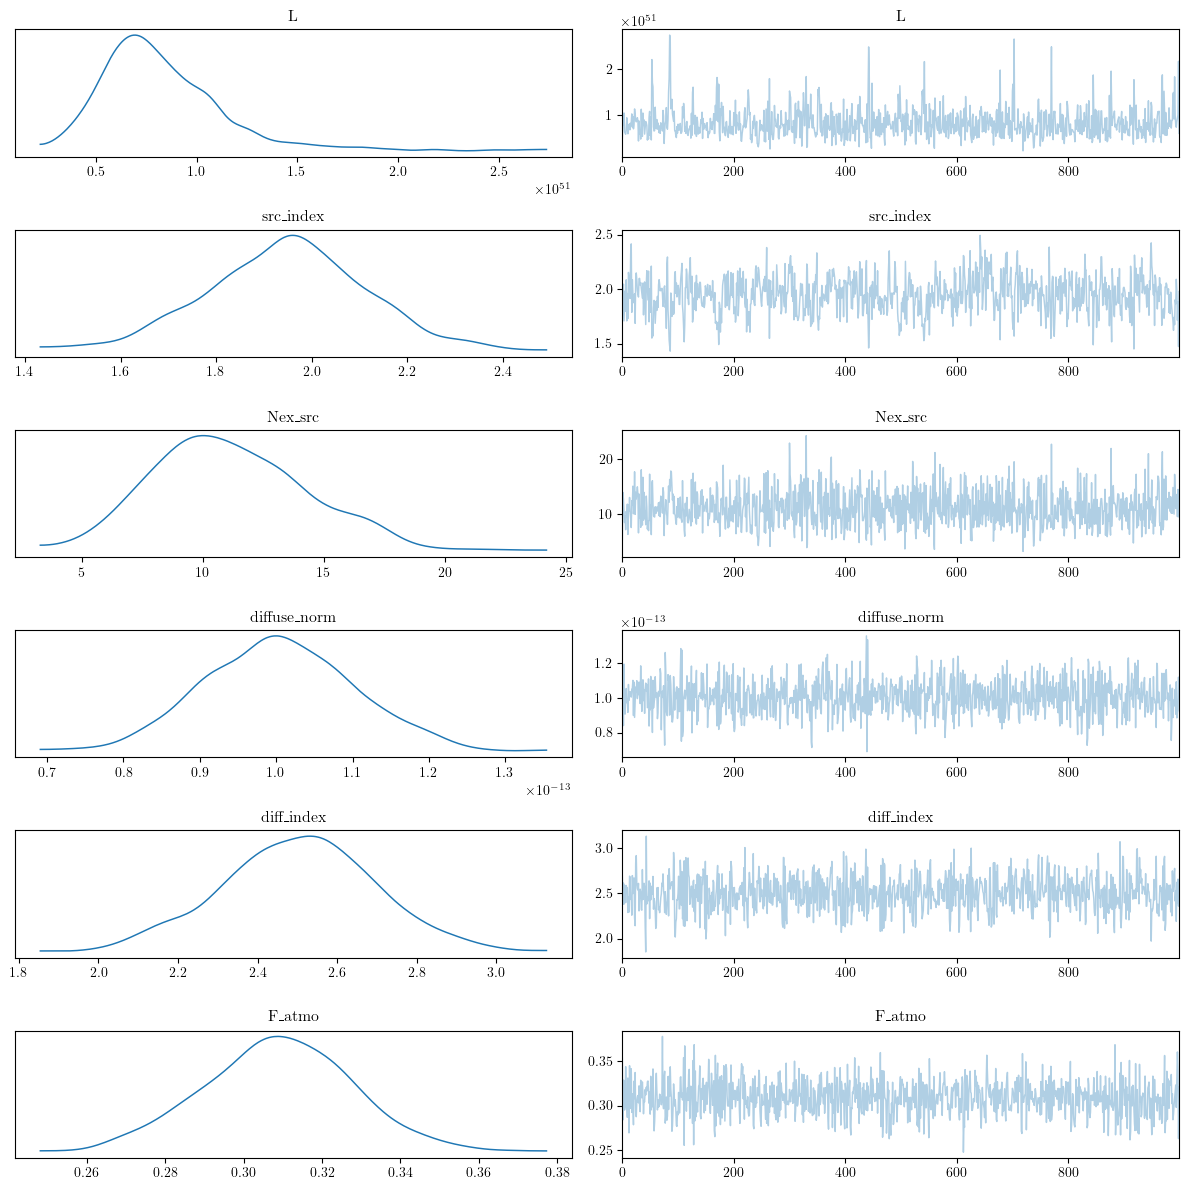

In [ ]:
fig, ax = fit.plot_trace()
fig.tight_layout()

We can also overplot the used priors (if there are priors available for the variables) by calling a different method. Both return a list of axes.

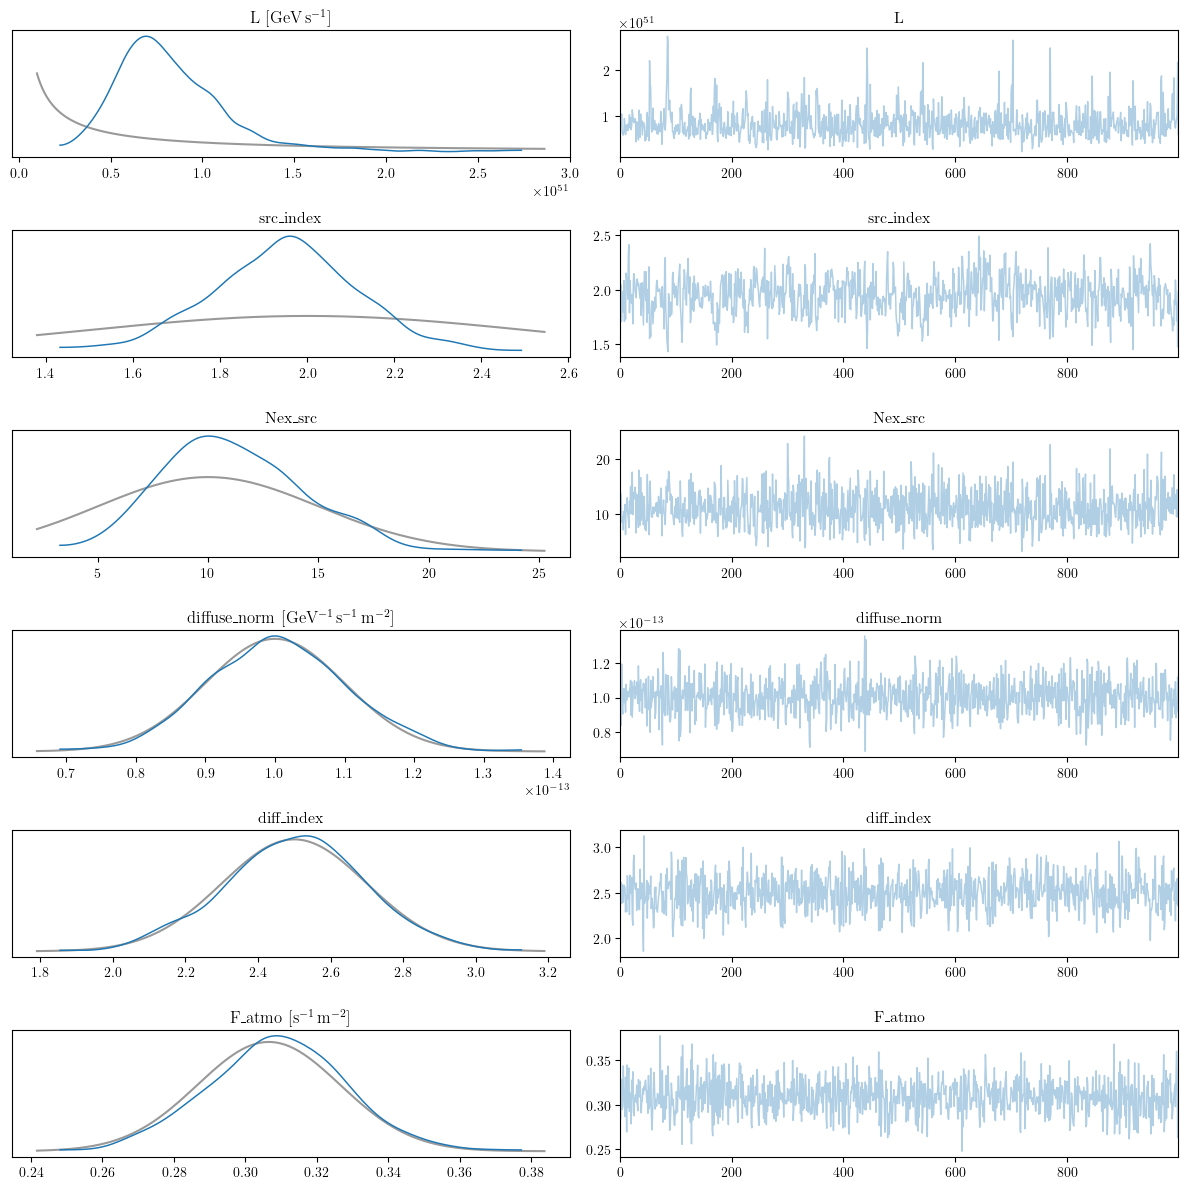

In [22]:
fig, ax = fit.plot_trace_and_priors()
fig.tight_layout()

In [23]:
fit.save("test_fit.h5", overwrite=True)

PosixPath('/home/iwsatlas1/kuhlmann/icecube/hierarchical_nu/examples/test_fit.h5')

We can check the results of the fit against the known true values from the above simulation. The `SimInfo` class pulls the interesting information out of our saved simulation for this purpose. 

In [24]:
from hierarchical_nu.simulation import SimInfo

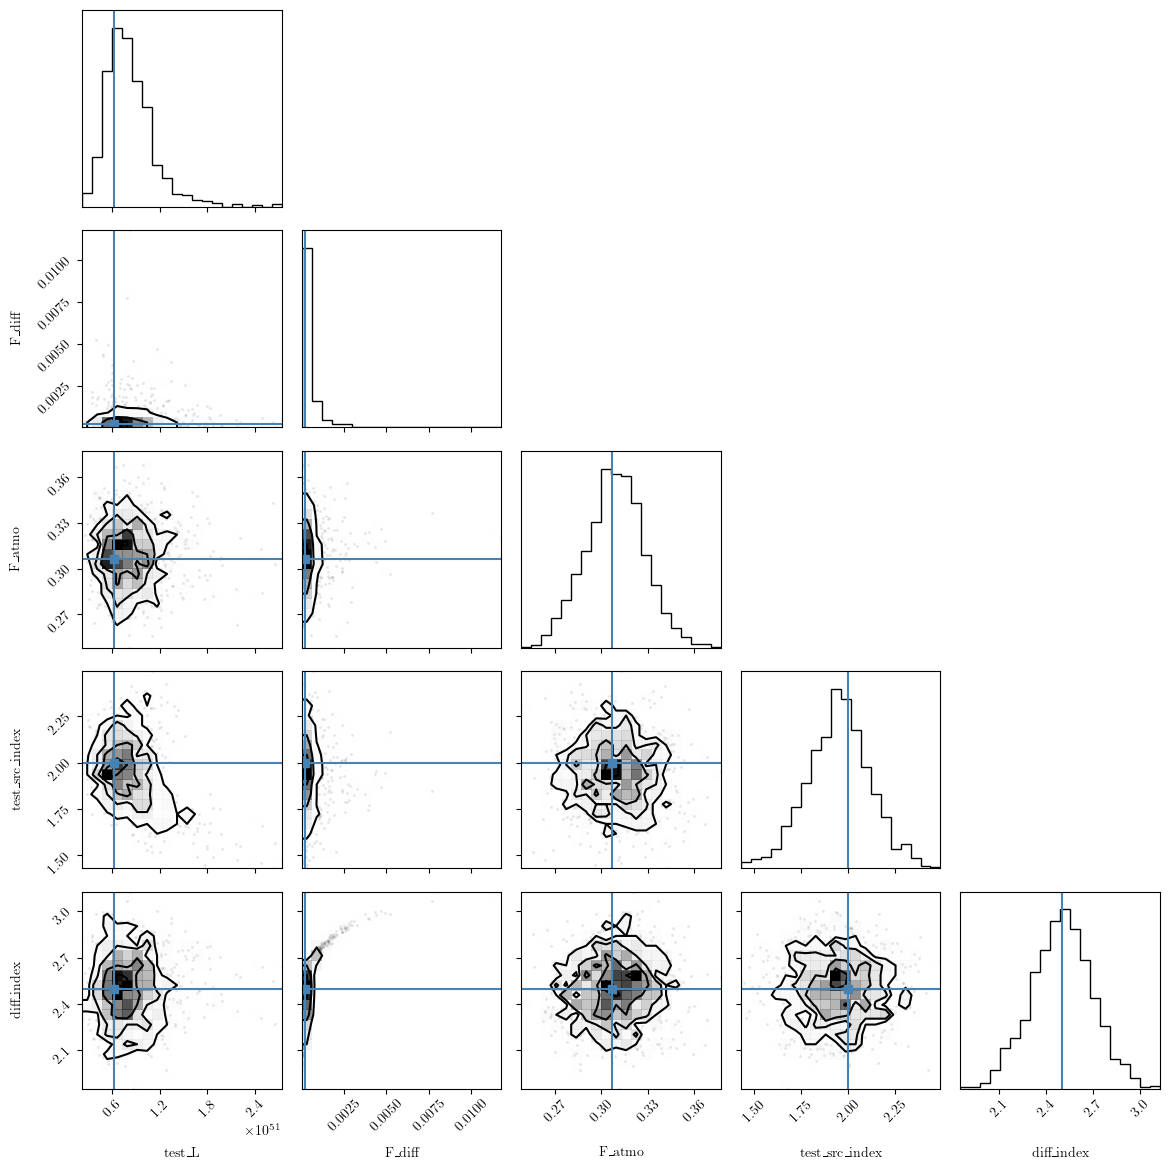

In [ ]:
sim_info = SimInfo.from_file("test_sim_file.h5")
fig = fit.corner_plot(
    var_names=[
        "L",
        "F_diff",
        "F_atmo",
        "src_index",
        "diff_index",
    ],
    truths=sim_info.truths,
)